# scDEF tutorial — interferon-stimulated PBMCs

Two batches of PBMCs, one **stimulated with interferon-beta** and one control (`stim` = STIM / CTRL). Batch is confounded with condition, so correction must *not* erase the real signal. This notebook runs the **same** reference → decompose → inspect-L0 procedure as the two-batch notebook, but the per-batch monocyte split turns out to be the genuine **interferon response** (CCL8, CXCL10, ISG15) — biological, and kept.

> **Running this notebook.** Fitting is the slow step — run top-to-bottom once; the fitted model is saved at the end, so you can re-open it with `scd.scDEF.load(...)` instead of re-fitting. The steps follow the reference [analysis workflow](../repo/docs/workflow.md).

## Load packages and data

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scdef as scd
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('../scdef_data/pbmcs_data/ifnb/ifnb.h5ad')
# Cell-type labels and condition live in the metadata csv.
adata.obs = pd.read_csv('../scdef_data/pbmcs_data/ifnb/ifnb_metadata.csv', index_col=0)
adata.raw = None
adata.layers['counts'] = adata.X.copy()  # X holds raw counts
adata.obs['stim'].value_counts()

stim
STIM    7451
CTRL    6548
Name: count, dtype: int64

In [3]:
# QC (following the paper preprocessing).
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=10)
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 5000, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

In [4]:
# HVG on counts, per batch; then a scanpy embedding for the colors.
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=4000, layer='counts',
                            batch_key='stim')
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

/home/pedro/.local/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:172: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


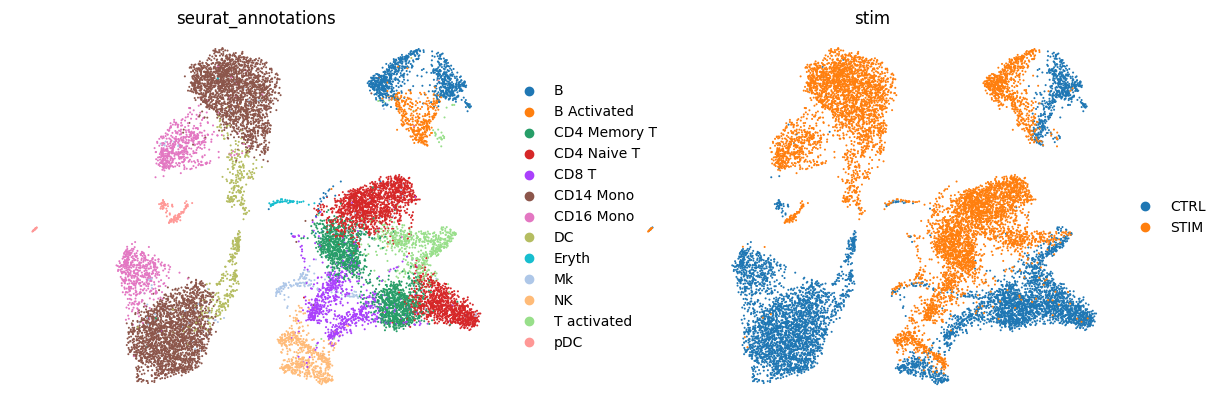

In [5]:
# A cell-state label that splits monocytes by condition (the effect of interest).
adata.obs['cell_state'] = adata.obs.apply(
    lambda r: f"{r['seurat_annotations']}_{r['stim']}" if 'Mono' in str(r['seurat_annotations'])
    else r['seurat_annotations'], axis=1).astype('category')
sc.pl.umap(adata, color=['seurat_annotations', 'stim'], frameon=False)

## Fit reference scDEF with batch annotations

In [6]:
ref = scd.scDEF(adata, counts_layer='counts', batch_key='stim')
print(ref)
ref.fit(hierarchical_init=True)

INFO:scDEF:Found 2 values for `stim` in data: ['CTRL' 'STIM']


scDEF object with 6 layers
	Layer names: L0, L1, L2, L3, L4, L5
	Layer sizes: 100, 40, 16, 6, 3, 1
	alpha parameter: 4.44
	Using BRD
	Number of batches: 2
Contains AnnData object with n_obs × n_vars = 13999 × 4000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'seurat_annotations', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'cell_state'
    var: 'features', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'seurat_annotations_colors', 'stim_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'


INFO:scDEF:Built hierarchical z/W init from KMeans (100 L0 clusters) using 'X_pca'.
INFO:scDEF:Each epoch contains 55 batches of size 256
100%|██████████| 1000/1000 [32:13<00:00,  1.93s/it, Loss=1.13e+7, Rel. impr.=-0.000113]
INFO:scDEF:Stopping learning: reached max epochs (n_epoch=1000).
INFO:scDEF:Updated adata.var: `gene_scale_0` for batch 0.
INFO:scDEF:Updated adata.var: `gene_scale_1` for batch 1.
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2
INFO:scDEF:Updated adata.obsm with layer 2: `X_L2`
INFO:scDEF:Updated adata.uns

## Check, diagnose, filter, re-fit, signatures

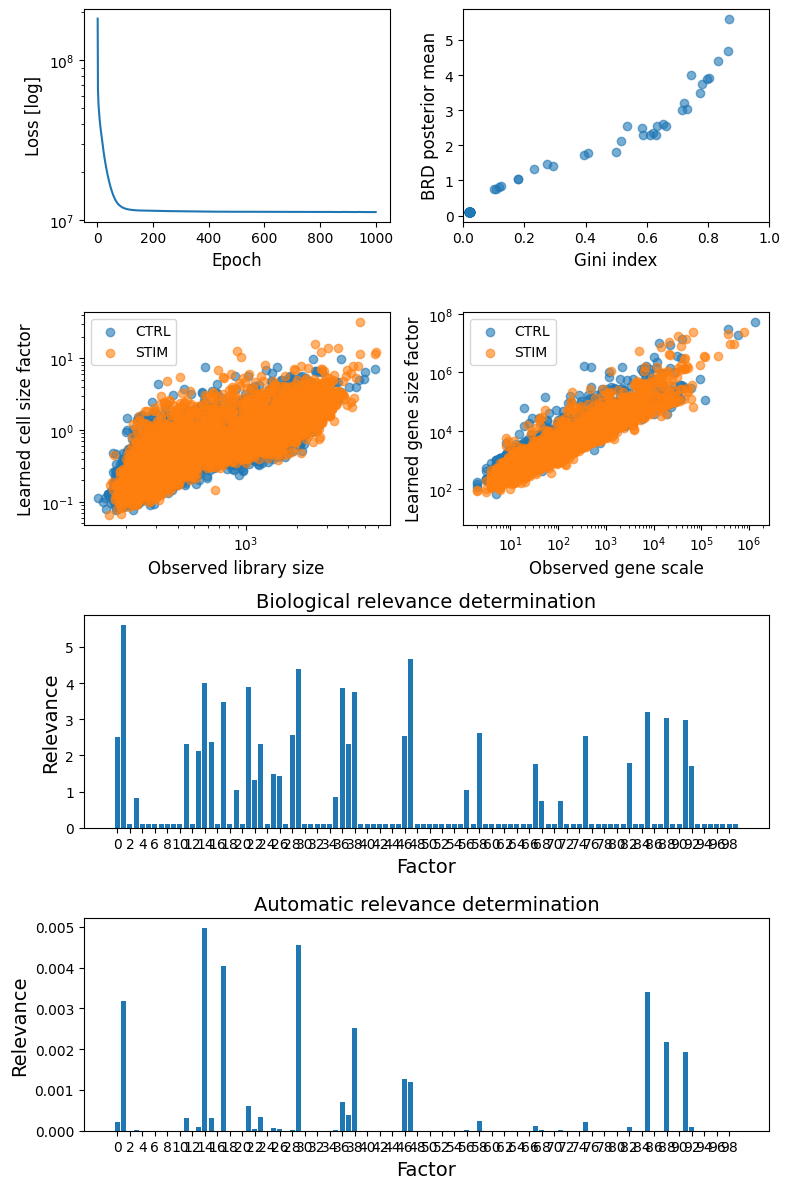

In [7]:
scd.pl.qc(ref)

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 1)).


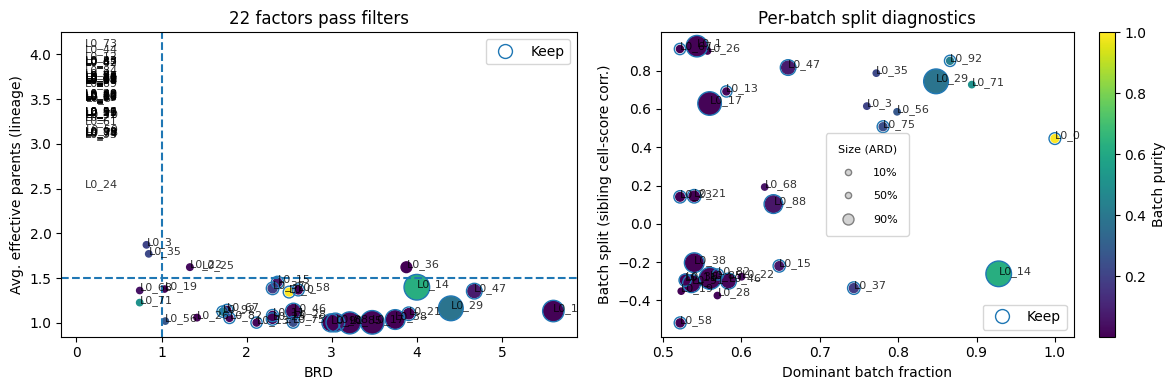

INFO:scDEF:filter_factors: cleared name-keyed caches (L0_signatures, L1_signatures, L2_signatures, L3_signatures, L4_signatures, L5_signatures, _factor_obs_fit_revision, _factor_obs_upper_lists_fixed, confident_signatures, factor_signatures). Re-run scdef.tools.set_confident_signatures to rebuild signatures, or scdef.tools.factor_diagnostics for the full diagnostics.
INFO:scDEF:Updated adata.var: `gene_scale_0` for batch 0.
INFO:scDEF:Updated adata.var: `gene_scale_1` for batch 1.
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0_signatures`.
INFO:scDEF:Updated adata.obs with layer 1: `L1` and `L1_score` for all factors in layer 1
INFO:scDEF:Updated adata.obsm with layer 1: `X_L1`
INFO:scDEF:Updated adata.uns with layer 1 signatures: `L1_signatures`.
INFO:scDEF:Updated adata.obs with layer 2: `L2` and `L2_score` for all factors in layer 2


[22, 13, 8, 3, 1]


In [8]:
scd.tl.factor_diagnostics(ref, batch_key='stim')
scd.pl.factor_diagnostics(ref, annotate_factors=True)
scd.tl.filter(ref, batch_key='stim')
ref.fit(hierarchical_init=True)
print([len(fl) for fl in ref.factor_lists])

In [9]:
scd.tl.factor_diagnostics(ref, batch_key='stim')  # refreshes diagnostics + gene signatures

INFO:scDEF:factor_diagnostics: recomputing cached diagnostics (missing cached upper-layer factor lists; fit revision changed (-1 -> 2)).


## Only monocytes split by condition

Across layers cell types separate and the two conditions mix — *except* the monocytes, which split by condition (`cell_state`). That split is biological signal to keep, not remove.

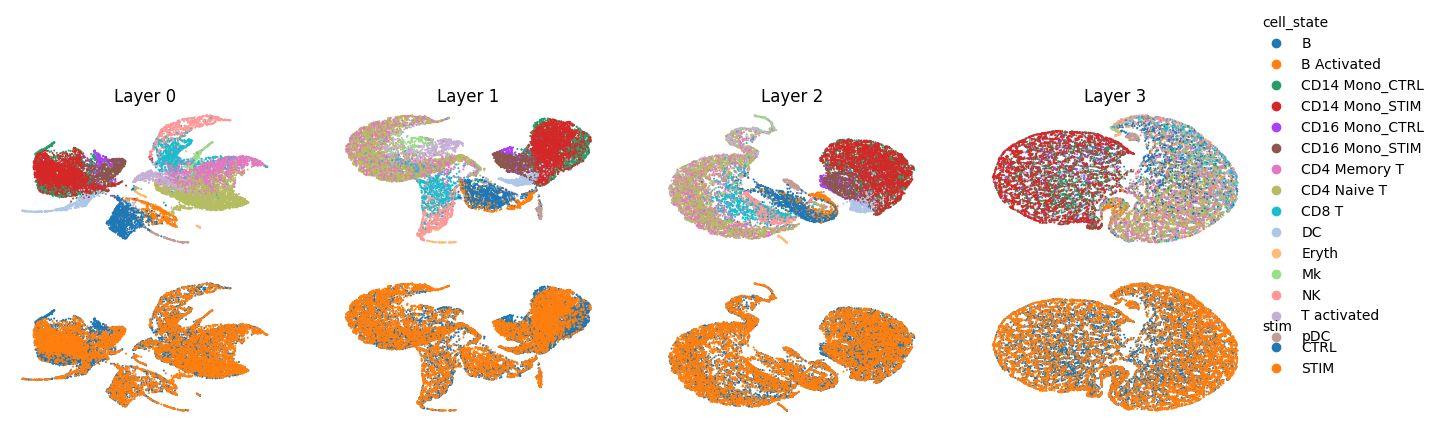

In [10]:
scd.tl.umap(ref)
scd.pl.umap(ref, color=['cell_state', 'stim'])

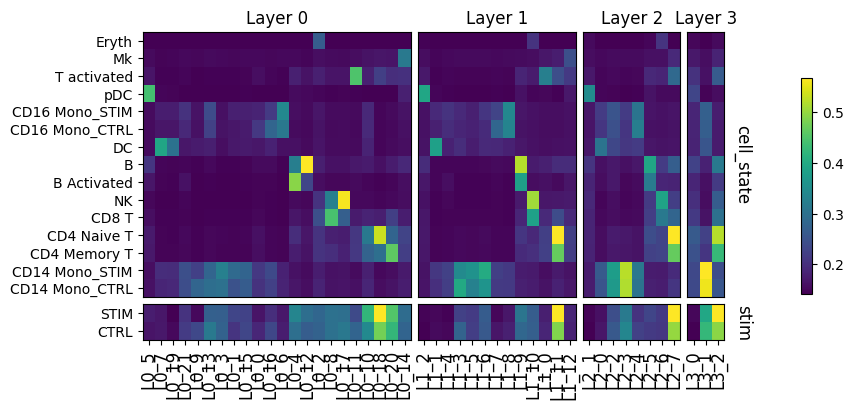

In [11]:
scd.pl.obs_scores(ref, ['cell_state', 'stim'], mode='weights')

INFO:scDEF:Updated scDEF graph


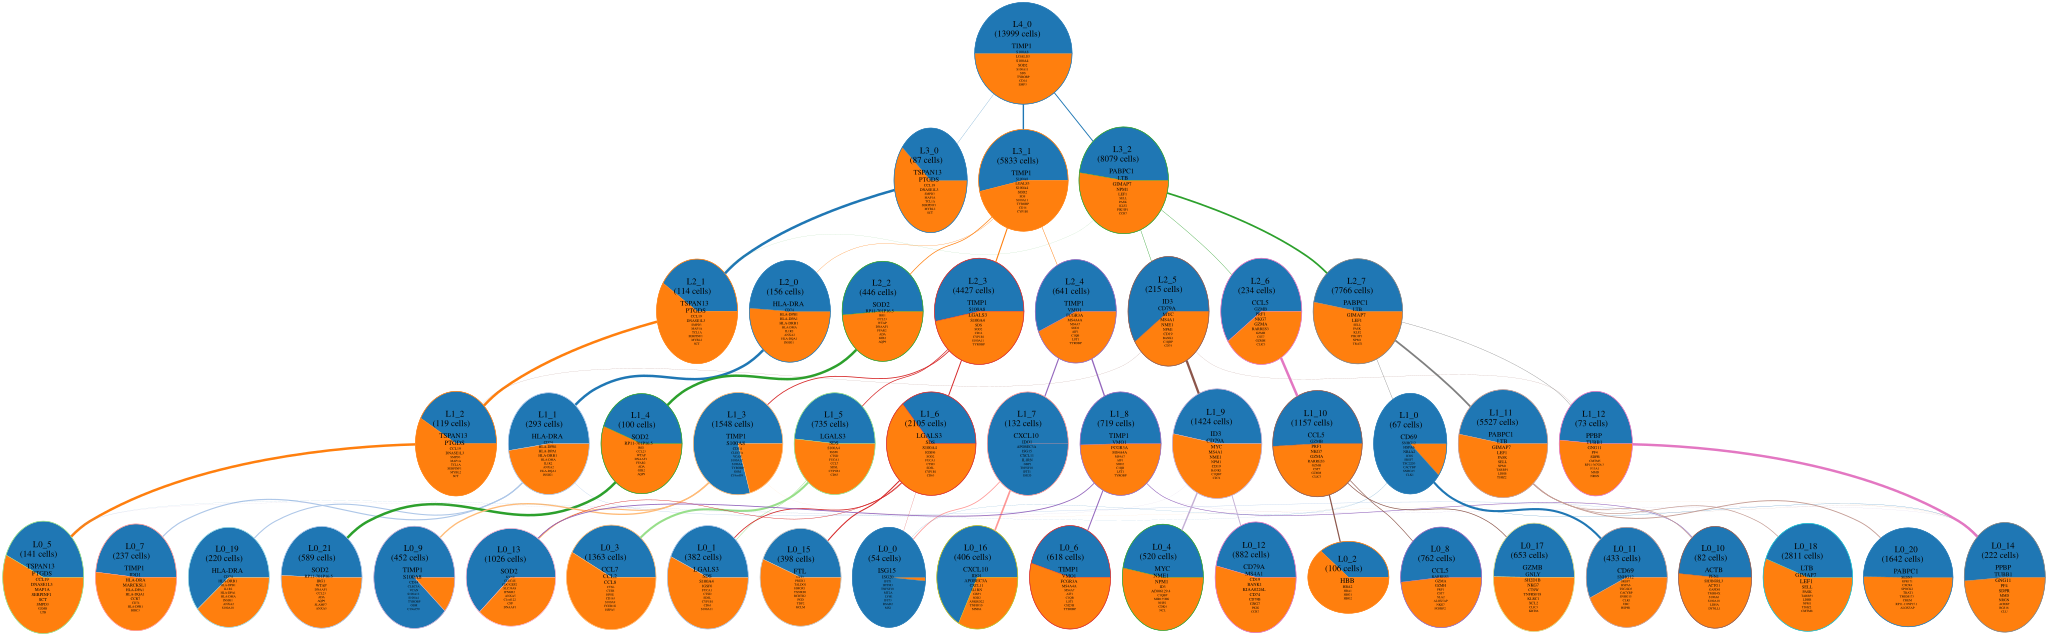

In [12]:
scd.pl.make_graph(ref, wedged='stim', show_signatures=True, n_cells_label=True)

## Decompose and inspect layer 0

Same procedure as the two-batch notebook: re-learn layer 0 without the batch term and read the batch-structure report. Fitting with `batch_key` pushed the condition signal into the per-batch gene scale, so everything condition-specific is clearest on the decomposed model **`dec`** — that's where the interferon factors re-appear.

In [13]:
dec = scd.scDEF.decompose_batch_effects(ref, top_layer=1)
scd.tl.factor_diagnostics(dec, batch_key='stim')  # batch structure + gene signatures for decomposed L0
rep = scd.tl.batch_structure_report(dec, batch_key='stim')  # `shape` = each L0 factor's batch structure
rep

INFO:scDEF:batch_cell_scale=True: keeping the per-batch cell_scale prior from `stim` (2 batches) while gene_scale stays a single shared row.
INFO:scDEF:Found 2 values for `stim` in data: ['CTRL' 'STIM']
INFO:scDEF:batch_gene_scale=False: keeping a single shared `gene_scale` row while fitting the per-batch `cell_scale` prior.
INFO:scDEF:Each epoch contains 55 batches of size 256
 50%|█████     | 200/400 [05:16<05:16,  1.58s/it, Loss=1.18e+7, Rel. impr.=-0.000433]
INFO:scDEF:Converged at epoch 201.
INFO:scDEF:filter_factors: cleared name-keyed caches (L0_signatures, L1_signatures, L2_signatures, L3_signatures, L4_signatures). Re-run scdef.tools.set_confident_signatures to rebuild signatures, or scdef.tools.factor_diagnostics for the full diagnostics.
INFO:scDEF:Updated adata.var: `gene_scale`
INFO:scDEF:Updated adata.obs with layer 0: `L0` and `L0_score` for all factors in layer 0
INFO:scDEF:Updated adata.obsm with layer 0: `X_L0`
INFO:scDEF:Updated adata.uns with layer 0 signatures: `L0

,n_cells,dom_batch,frac_dom_batch,batch_purity_soft,loading_ratio,eff_parents,parent,opp_batch_sibling,branch_auc,shape,gene_scale_affinity_CTRL,gene_scale_affinity_STIM,gene_scale_affinity_max,gene_scale_affinity_batch
L0,,,,,,,,,,,,,,
L0_0,74,STIM,1.000000,0.904697,9.738697,4.213228,L1_7,False,NaN,overlaid,-0.188413,0.188413,0.188413,STIM
L0_9,505,CTRL,0.996040,0.845527,1.781735,1.002566,L1_3,False,1.000000,branch_skewed,0.351907,-0.351907,0.351907,CTRL
L0_16,893,STIM,0.993281,0.811740,0.958029,1.013222,L1_7,False,NaN,branch_skewed,-0.292352,0.292352,0.292352,STIM
L0_13,1192,CTRL,0.988255,0.739050,2.770896,2.006315,L1_3,False,1.000000,overlaid,0.183754,-0.183754,0.183754,CTRL
L0_15,313,CTRL,0.964856,0.670304,1.801528,1.678150,L1_6,True,0.999994,overlaid,0.133233,-0.133233,0.133233,CTRL
L0_1,324,STIM,0.959877,0.661677,0.764480,1.424733,L1_6,True,0.999994,branch_split,-0.219346,0.219346,0.219346,STIM
L0_19,167,CTRL,0.868263,0.612255,1.841799,1.051181,L1_1,True,0.999722,branch_split,0.159907,-0.159907,0.159907,CTRL
L0_3,1238,STIM,0.857027,0.716951,0.782863,1.014604,L1_5,False,0.999978,branch_skewed,-0.109171,0.109171,0.109171,STIM
L0_10,70,CTRL,0.785714,0.504550,1.396903,2.846410,L1_8,False,0.999415,overlaid,0.210087,-0.210087,0.210087,CTRL


## Which factors respond to the condition, within a cell type

On `dec`, a per-cell factor heatmap restricted to one cell type and grouped by condition shows *which* factors carry the response (`values='prob'` = normalized memberships). Stimulated monocytes light up a block of interferon factors that control monocytes lack. Naive CD4 T cells share the broad **ISG** factor (interferon-stimulated genes are pan-cellular) but *not* the monocyte-specific **chemokine** factors (CCL8/CXCL10) — the response is part shared, part cell-type-shaped.

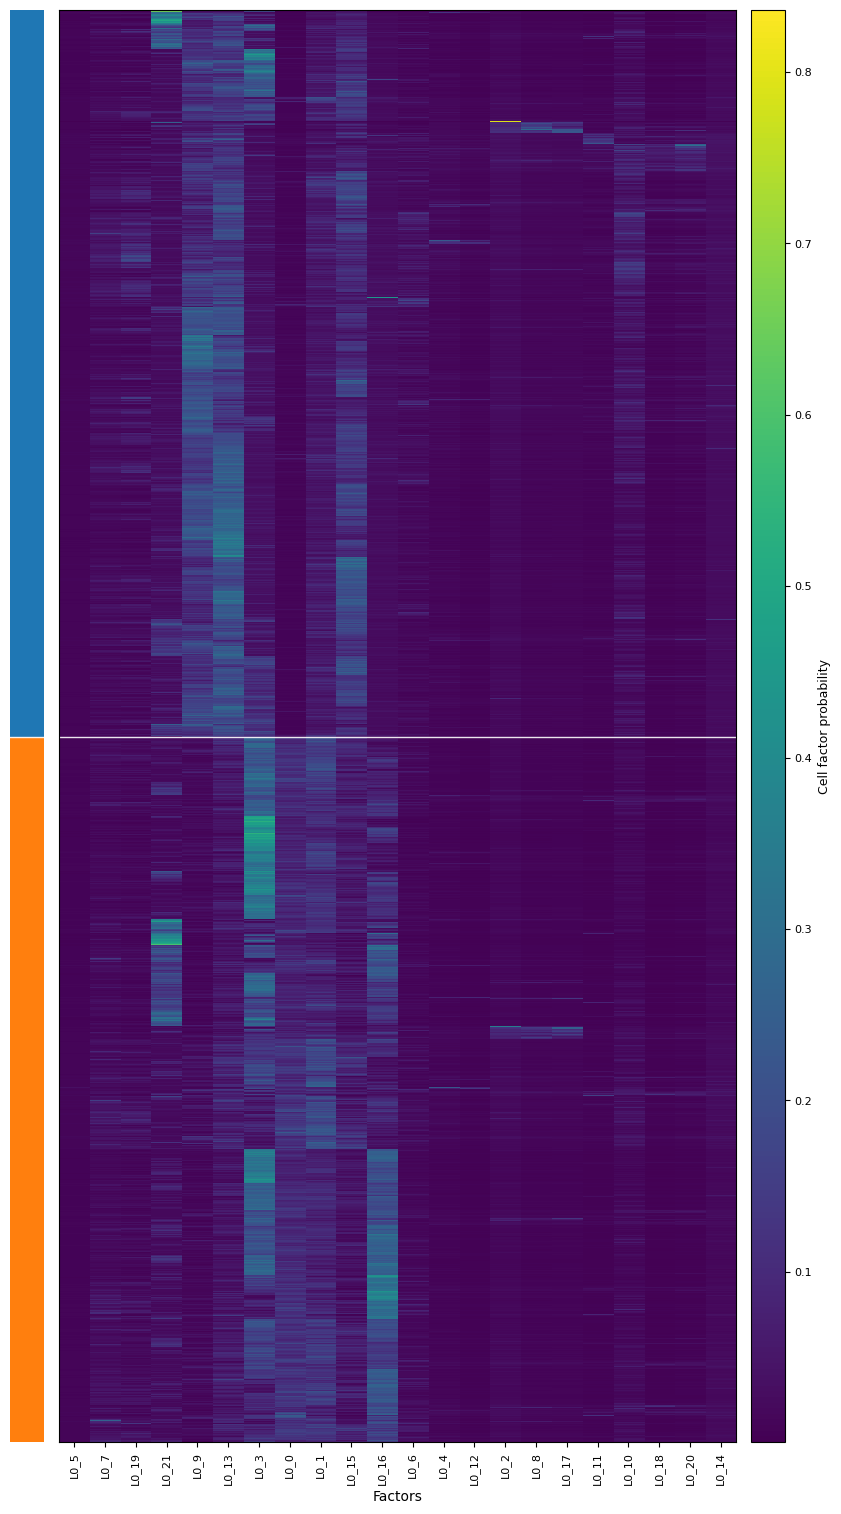

In [14]:
scd.pl.obs_cell_factor_heatmap(dec, subset_obs_key='seurat_annotations',
                               subset_obs='CD14 Mono', group_obs_key='stim', values='prob')

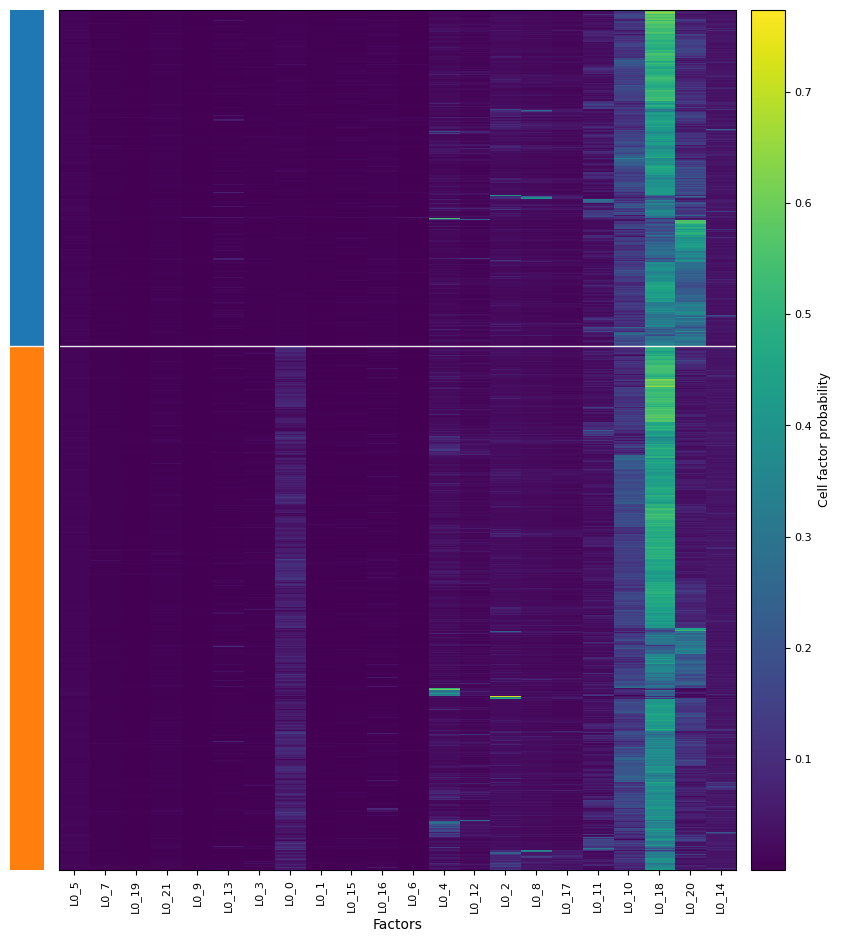

In [15]:
scd.pl.obs_cell_factor_heatmap(dec, subset_obs_key='seurat_annotations',
                               subset_obs='CD4 Naive T', group_obs_key='stim', values='prob')

## Biological vs technical decision

The report describes only geometry. Run the *same* flagging line as the two-batch notebook, then inspect what it caught: the batch-skewed monocyte factors carry the interferon response (CCL8/CXCL10/ISG15). That is **biological** — a real, cell-type-specific reaction — so, unlike the two-batch case, we **deliberately do not** call `set_batch_technical_factors`.

In [16]:
flagged = rep.index[rep['shape'].isin(['branch_split', 'branch_skewed'])]
print('batch-skewed factors:', list(flagged))
sigs = scd.tl.get_stored_confident_signatures(dec, layer_idx=0, max_genes=10)
sigs = sigs[0] if isinstance(sigs, tuple) else sigs
for f in flagged:
    print(f, list(sigs.get(f, []))[:10])   # the interferon program sits among these -> keep

batch-skewed factors: ['L0_9', 'L0_16', 'L0_1', 'L0_19', 'L0_3']
L0_9 ['S100A8', 'CLEC5A', 'PID1', 'VCAN', 'THBS1', 'CTB-61M7.2', 'IL8', 'CD14', 'TIMP1', 'C19orf59']
L0_16 ['CXCL10', 'CXCL11', 'APOBEC3A', 'FAM26F', 'TNFSF10', 'IFITM3', 'IDO1', 'HSPA1A', 'ANKRD22', 'IFIT2']
L0_1 ['APOBEC3A', 'HSPA1A', 'IGSF6', 'TYROBP', 'SGK1', 'SDSL', 'HSPB1', 'TYMP', 'LILRB4', 'FCN1']
L0_19 ['HLA-DRA', 'HLA-DRB1', 'CD74', 'LYZ', 'HLA-DPB1', 'HLA-DPA1', 'HLA-DMA', 'IL1R2', 'HLA-DQB1', 'PKIB']
L0_3 ['CCL2', 'CCL8', 'APOBEC3B', 'CCL7', 'RSAD2', 'CTSL', 'LYZ', 'S100A9', 'CTSB', 'SDS']


INFO:scDEF:Updated scDEF graph


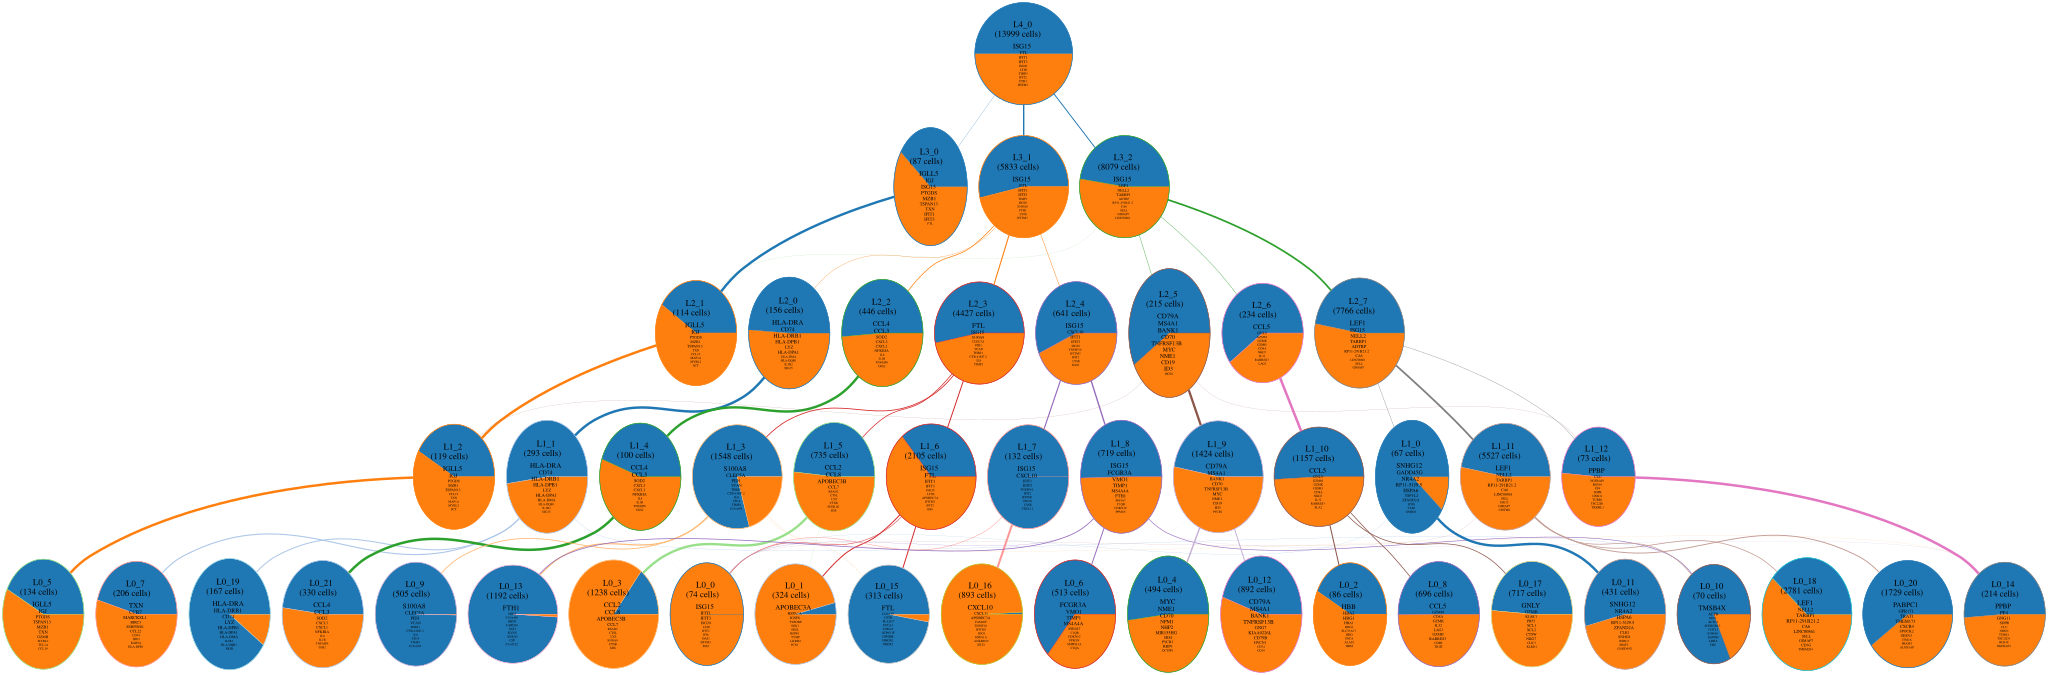

In [17]:
scd.pl.make_graph(dec, wedged='stim', show_signatures=True, n_cells_label=True)

**Conclusion.** On healthy batches (the two-batch notebook) the same report yields technical per-batch splits, which we fold away with `set_batch_technical_factors` + `factor_batch_correction`. Here the identical geometry is a biological, cell-type-specific response — so we leave it untouched. Same procedure, opposite decision, made from the experimental design.

## Save the fitted models

In [18]:
ref.save('scdef-ifn-ref', overwrite=True)
dec.save('scdef-ifn-dec', overwrite=True)